# 01. Quantum field theory at tree level

This notebook does the calculations of a first course in quantum field theory with feynsage: Dirac traces,
spin sums, squared amplitudes, cross sections and decay widths, for QED, QCD and the electroweak theory.
Every result is compared with the textbook formula it should give. If you have never used Python or Sage,
do `00_start_here.ipynb` first.

**Conventions.** Natural units ħ = c = 1, energies in GeV, the metric (+, −, −, −) and the Dirac matrices of
Peskin and Schroeder, *An Introduction to Quantum Field Theory* (1995); equation and page numbers below
refer to that book (pages as printed). The Mandelstam variables of a 2 → 2 process p1 + p2 → p3 + p4 are
s = (p1 + p2)², t = (p1 − p3)², u = (p1 − p4)².

**The recipe of every tree-level calculation.**
1. draw the diagrams;
2. write the amplitude M with the Feynman rules;
3. multiply M by its complex conjugate and sum over spins, polarizations and colours;
4. put in the kinematics (s, t, u, or energies and angles);
5. multiply by the phase space: a cross section or a decay width.

feynsage can do each step separately (sections 1 and 2) or all of them in one line (section 3 onward).

In [1]:
from feynsage import *
from feynsage.models import EL, ME, MM, GS, MW, MZ, SW, CW, MH, MB, MT

## 1. Dirac matrices and traces

`momenta("p q k")` makes three four-vectors and `lorentz_indices("mu nu")` two Lorentz indices. In the
expressions, `Dot(p, q)` is p·q, `Metric(mu, nu)` is g^{μν} and `Comp(p, mu)` is p^μ. The algebra itself is
done by the program FORM, which feynsage calls for you.

In [2]:
p, q, k, l = momenta("p q k l")
mu, nu, rho, sig = lorentz_indices("mu nu rho sigma")

show(dirac_trace(gamma(mu)*gamma(nu)))                 # Tr[g^mu g^nu] = 4 g^{mu nu}
show(dirac_trace(slash(p)*slash(q)))                   # Tr[p/ q/] = 4 p.q
show(dirac_trace(slash(p)*slash(q)*slash(k)*slash(l))) # the four-gamma trace

4*Metric(mu, nu)

4*Dot(p, q)

4*Dot(k, q)*Dot(l, p) - 4*Dot(k, p)*Dot(l, q) + 4*Dot(k, l)*Dot(p, q)

With γ5 = iγ⁰γ¹γ²γ³ the trace of four gammas and γ5 is −4i ε^{μνρσ} (Peskin's convention, ε^{0123} = +1):

In [3]:
dirac_trace(gamma(mu)*gamma(nu)*gamma(rho)*gamma(sig)*gamma5())

-4*I*Epsilon(mu, nu, rho, sigma)

Contractions like γ^μ p̸ γ_μ = −2p̸ (in four dimensions) and the same in d dimensions, where they change:

In [4]:
show(simplify_dirac(gamma(mu)*slash(p)*gamma(mu)))
show(simplify_dirac(gamma(mu)*slash(p)*gamma(mu), dim='d'))

-2*slash(p)

(-d + 2)*slash(p)

## 2. e⁺e⁻ → μ⁺μ⁻ by hand: spinors and the spin sum

The amplitude of e⁻(p1) e⁺(p2) → μ⁻(p3) μ⁺(p4) with one photon in the s channel is

M = (e²/s) [ū(p3) γ^μ v(p4)] [v̄(p2) γ_μ u(p1)].

`u, v, ubar, vbar` are the spinors, `conjugate` makes M*, and `spin_sum` replaces u ū by p̸ + m and
v v̄ by p̸ − m, so the sum over spins becomes two traces.

In [5]:
p1, p2, p3, p4 = momenta("p1 p2 p3 p4")
s, t, u_ = SR.var('s t u')     # SR.var is like var, but it does not take the name u away from the spinor u()
M = EL^2/s * (ubar(p3, MM)*gamma(mu)*v(p4, MM)) * (vbar(p2, ME)*gamma(mu)*u(p1, ME))
summed = spin_sum(M*conjugate(M))
summed

64*EL^4*ME^2*MM^2/s^2 + 32*EL^4*MM^2*Dot(p1, p2)/s^2 + 32*EL^4*ME^2*Dot(p3, p4)/s^2 + 32*EL^4*Dot(p1, p4)*Dot(p2, p3)/s^2 + 32*EL^4*Dot(p1, p3)*Dot(p2, p4)/s^2

Now the kinematics: every p_i·p_j in s, t, u and the masses. The result, divided by 4 for the average over
the spins of e⁻ and e⁺, is the textbook formula.

In [6]:
kin = {dot(p1, p1): ME^2, dot(p2, p2): ME^2, dot(p3, p3): MM^2, dot(p4, p4): MM^2,
       dot(p1, p2): (s - 2*ME^2)/2, dot(p3, p4): (s - 2*MM^2)/2,
       dot(p1, p3): (ME^2 + MM^2 - t)/2, dot(p2, p4): (ME^2 + MM^2 - t)/2,
       dot(p1, p4): (ME^2 + MM^2 - u_)/2, dot(p2, p3): (ME^2 + MM^2 - u_)/2}
avg = (summed.subs(kin)/4).factor()
avg

2*(2*ME^4 + 4*ME^2*MM^2 + 2*MM^4 + 2*ME^2*s + 2*MM^2*s - 2*ME^2*t - 2*MM^2*t - 2*ME^2*u - 2*MM^2*u + t^2 + u^2)*EL^4/s^2

In [7]:
avg.subs({ME: 0, MM: 0}).factor()        # massless: 2 e^4 (t^2 + u^2)/s^2

2*(t^2 + u^2)*EL^4/s^2

## 3. The same in one line: `process`

`process("e- e+ -> mu- mu+")` makes the diagrams from a model (the Standard Model by default, or `model="QED"`),
writes the amplitude and does steps 1 to 4. `massless=["e"]` sets the electron mass to zero.

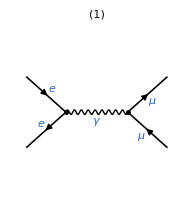

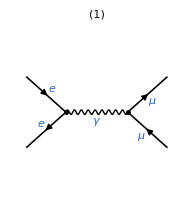

In [8]:
P = process("e- e+ -> mu- mu+", model="QED", massless=["e"])
P.draw()

In [9]:
P.squared().factor()                     # (1/4) sum over spins |M|^2, in s, t, u

2*(2*MM^4 + 2*MM^2*s - 2*MM^2*t - 2*MM^2*u + t^2 + u^2)*EL^4/s^2

In the centre-of-mass frame with E the beam energy and θ the angle between e⁻ and μ⁻, Peskin and Schroeder
find (Eq. (5.11), p. 136)

(1/4) Σ|M|² = e⁴ [ (1 + m_μ²/E²) + (1 − m_μ²/E²) cos²θ ].

`P.to_angles()` writes s, t, u in √s = 2E and cos θ:

In [10]:
E, c = var('E c')
assume(E > MM, MM > 0)                  # tells Sage that E > m_mu > 0, so square roots simplify
ours = P.squared().subs(P.to_angles()).subs({P.sqrt_s: 2*E, P.cos_theta: c})
peskin_511 = EL^4*((1 + MM^2/E^2) + (1 - MM^2/E^2)*c^2)
(ours - peskin_511).simplify_full()

0

The cross section. `P.dsigma_dcos()` is dσ/d cos θ; the total cross section is its integral over cos θ from −1
to 1. Peskin's Eq. (5.13), p. 136: σ = (4πα²/3E_cm²) √(1 − m_μ²/E²) (1 + m_μ²/2E²).

In [11]:
alpha = var('alpha')
dsig = P.dsigma_dcos().subs({EL: sqrt(4*pi*alpha)}).subs({P.sqrt_s: 2*E, P.cos_theta: c})
sigma = integrate(dsig, c, -1, 1)
peskin_513 = 4*pi*alpha^2/(3*(2*E)^2)*sqrt(1 - MM^2/E^2)*(1 + MM^2/(2*E^2))
show(sigma.canonicalize_radical().factor())
(sigma - peskin_513).canonicalize_radical()

1/6*pi*(2*E^2 + MM^2)*sqrt(E + MM)*sqrt(E - MM)*alpha^2/E^5

0

Numbers: `P.sigma(sqrt_s=...)` integrates numerically and puts in the measured constants (α = 1/137.036,
the particle masses). Here σ(e⁺e⁻ → μ⁺μ⁻) at three energies, in picobarn:

In [12]:
for rs in [1, 10, 100]:
    print("sqrt(s) =", rs, "GeV:  sigma =", P.sigma(sqrt_s=rs, unit="pb"), "pb")

sqrt(s) = 1 GeV:  sigma = 86788.5380408103 pb
sqrt(s) = 10 GeV:  sigma = 868.5447038001781 pb
sqrt(s) = 100 GeV:  sigma = 8.685447687504256 pb


## 4. Helicity amplitudes

Each helicity state can be asked for separately (massless fermions; +1 is right-handed, −1 left-handed). Peskin's
Eq. (5.21), p. 143: for e⁻_R e⁺_L → μ⁻_R μ⁺_L, |M|² = e⁴ (1 + cos θ)², and e⁻_R e⁺_L → μ⁻_L μ⁺_R gives
e⁴ (1 − cos θ)². Equal helicities of e⁻ and e⁺ give zero.

In [13]:
Q = process("e- e+ -> mu- mu+", model="QED", massless=["e", "mu"])
for h in [(+1, -1, +1, -1), (+1, -1, -1, +1), (+1, +1, +1, -1)]:
    hel = {"e-": h[0], "e+": h[1], "mu-": h[2], "mu+": h[3]}
    print(h, "  |M|^2 =", Q.squared(helicities=hel).factor())

(1, -1, 1, -1)   |M|^2 = EL^4*(cos_theta + 1)^2
(1, -1, -1, 1)   |M|^2 = EL^4*(cos_theta - 1)^2
(1, 1, 1, -1)   |M|^2 = 0


## 5. Compton scattering and pair annihilation

Compton scattering e⁻γ → e⁻γ. The photon polarizations are summed with −g^{μν} (allowed by the Ward
identity). Peskin's Eq. (5.87), p. 162, written with p·k = (s − m²)/2 and p·k′ = (m² − u)/2:

(1/4) Σ|M|² = 2e⁴ [ p·k′/p·k + p·k/p·k′ + 2m²(1/p·k − 1/p·k′) + m⁴(1/p·k − 1/p·k′)² ].

In [14]:
C = process("e- gamma -> e- gamma", model="QED")
s, t, u = C.s, C.t, C.u
pk, pkp = (s - ME^2)/2, (ME^2 - u)/2
peskin_587 = 2*EL^4*(pkp/pk + pk/pkp + 2*ME^2*(1/pk - 1/pkp) + ME^4*(1/pk - 1/pkp)^2)
(C.squared() - peskin_587).subs(u=2*ME^2 - s - t).simplify_rational()

0

The Klein–Nishina formula follows in the lab frame; here instead the crossed process e⁺e⁻ → γγ, Peskin's
(5.105) and (5.106), p. 168. The book's dσ/d cos θ has no factor 1/2 for the two identical photons;
`dsigma_dcos()` includes it, so we compare twice our value.

In [15]:
A = process("e- e+ -> gamma gamma", model="QED")
pp = sqrt(E^2 - ME^2)
peskin_5106 = 2*pi*alpha^2/(4*E^2)*(E/pp)*((E^2 + pp^2*c^2)/(ME^2 + pp^2*(1 - c^2))
              + 2*ME^2/(ME^2 + pp^2*(1 - c^2)) - 2*ME^4/(ME^2 + pp^2*(1 - c^2))^2)
ours = 2*A.dsigma_dcos().subs({EL: sqrt(4*pi*alpha)}).subs({A.sqrt_s: 2*E, A.cos_theta: c})
(ours - peskin_5106).subs({E: 3, c: 1/3, ME: 1, alpha: 1/137}).n(digits=30)

9.02779661431516806119989660587e-36

## 6. Identical fermions: Bhabha and Møller scattering

With identical fermions there are two diagrams and a relative minus sign between them (Fermi statistics).
feynsage finds the sign from the order of the fermion lines.

In [16]:
for text in ["e- e+ -> e- e+", "e- e- -> e- e-"]:
    R = process(text, model="QED", massless=["e"])
    print(text, ":", len(R.diagrams), "diagrams")
    show(R.squared().factor())

e- e+ -> e- e+ : 2 diagrams


2*(s^4 + t^4 + s^2*u^2 + 2*s*t*u^2 + t^2*u^2)*EL^4/(s^2*t^2)

e- e- -> e- e- : 2 diagrams


2*(s^2*t^2 + t^4 + 2*s^2*t*u + s^2*u^2 + u^4)*EL^4/(t^2*u^2)

## 7. Colour: QCD

Quarks carry colour (N = 3) and gluons are in the adjoint representation. `color_factor` sums colour indices
with Tr(T^a T^b) = δ^{ab}/2. Two standard numbers: T^a T^a = C_F 1 with C_F = 4/3, and f^{acd} f^{bcd} = N δ^{ab}.

In [17]:
a, b, c_, d = color_indices("a b c d")
i, j = quark_colors("i j")
show(color_factor(T_color(a, i, j)*T_color(a, j, i), N=3))     # Tr(T^a T^a) = (N^2 - 1)/2 = 4
show(color_factor(f_color(a, c_, d)*f_color(b, c_, d), N=3))   # N delta^{ab}

4

3*Kron(a, b)

u ū → g g: three diagrams (one with the three-gluon vertex). Only the two physical polarizations of each
gluon are summed. The result (averaged over the 2 × 2 spins and 3 × 3 colours of the quarks) is
(32/27) g⁴ [t/u + u/t − (9/4)(t² + u²)/s²], as in the solutions of Peskin's problems by Zhong-Zhi Xianyu,
his Eq. (17.23).

In [18]:
G = process("u u~ -> g g", exclude_fields=["A", "Z", "H", "G0", "G+", "W+"], massless=["u"])
s, t, u = G.s, G.t, G.u
r = G.squared()
show(r.subs(s=-t - u).factor())
(r - 32*GS^4/27*(t/u + u/t - 9*(t^2 + u^2)/(4*s^2))).subs(s=-t - u).simplify_rational()

8/27*(4*t^2 - t*u + 4*u^2)*(t^2 + u^2)*GS^4/((t + u)^2*t*u)

0

Four gluons (four diagrams, with the four-gluon vertex) take about half a minute. The result is the compact
(9/2) g⁴ (3 − tu/s² − su/t² − st/u²):

In [19]:
GG = process("g g -> g g", exclude_fields=["A", "Z", "H", "G0", "G+", "W+"])
s, t, u = GG.s, GG.t, GG.u
r = GG.squared()
(r - 9*GS^4/2*(3 - t*u/s^2 - s*u/t^2 - s*t/u^2)).subs(u=-s - t).simplify_rational()

0

## 8. The electroweak theory: e⁺e⁻ → W⁺W⁻

In the Standard Model, e⁺e⁻ → W⁺W⁻ has a neutrino in the t channel and a photon and a Z in the s channel
(and a Higgs diagram, which is zero for a massless electron). Each diagram alone grows with the
energy, but their sum does not: the gauge cancellation that keeps the theory unitary (Peskin, Section 21.2).
`diagrams=[k]` keeps only diagram k.

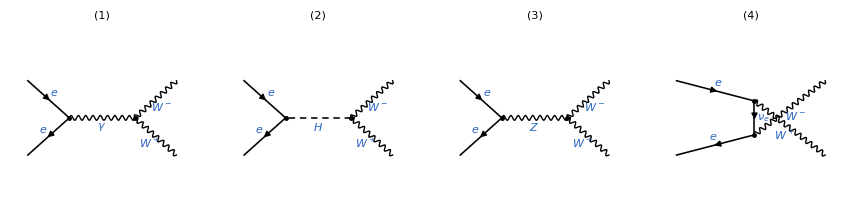

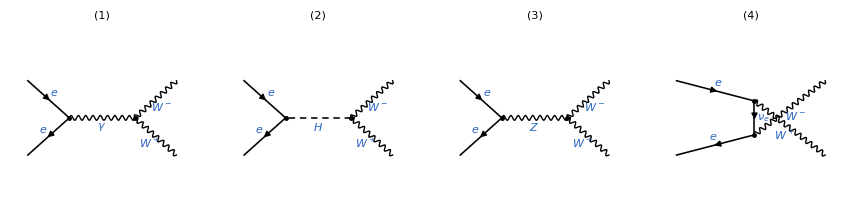

In [20]:
W = process("e- e+ -> W+ W-", massless=["e"])
W.draw()

In [21]:
full = W.squared()
parts = [W.squared(diagrams=[k]) for k in range(1, len(W.diagrams) + 1)]
for rs in [200, 500, 1000, 3000]:
    vals = [W.numeric(x.subs(W.to_angles()), sqrt_s=rs, cos_theta=0.3) for x in [full] + parts]
    print("sqrt(s) = %5d GeV   all diagrams: %.3e    one by one:" % (rs, vals[0]),
          ["%.2e" % v for v in vals[1:]])

sqrt(s) =   200 GeV   all diagrams: 6.303e-02    one by one: ['4.55e-02', '0.00e+00', '9.22e-02', '3.13e-01']


sqrt(s) =   500 GeV   all diagrams: 2.131e-02    one by one: ['1.75e+00', '0.00e+00', '2.37e+00', '4.89e+00']
sqrt(s) =  1000 GeV   all diagrams: 1.815e-02    one by one: ['2.43e+01', '0.00e+00', '3.14e+01', '6.27e+01']


sqrt(s) =  3000 GeV   all diagrams: 1.728e-02    one by one: ['1.87e+03', '0.00e+00', '2.38e+03', '4.71e+03']


For longitudinal W bosons at high energy the amplitude equals that of the Goldstone bosons (the equivalence
theorem). Peskin's Eq. (21.107), p. 756, gives the limit of the e⁻_L e⁺_R → W⁺_0 W⁻_0 amplitude,
e² sin θ/(4 s_W² c_W²), so |M|² goes to e⁴ sin²θ/(16 s_W⁴ c_W⁴). The ratio of feynsage's helicity state to
that limit goes to 1:

In [22]:
M00 = W.squared(helicities={"e-": -1, "e+": +1, "W+": 0, "W-": 0})
c0 = 0.5
limit = EL^4*(1 - c0^2)/(16*SW^4*CW^4)
for rs in [300, 1000, 5000, 20000]:
    ratio = W.numeric(M00/limit, sqrt_s=rs, cos_theta=c0).n()
    print("sqrt(s) = %6d GeV   |M|^2 / limit = %.6f" % (rs, ratio.real()))

sqrt(s) =    300 GeV   |M|^2 / limit = 1.866936


sqrt(s) =   1000 GeV   |M|^2 / limit = 1.059213


sqrt(s) =   5000 GeV   |M|^2 / limit = 1.002311


sqrt(s) =  20000 GeV   |M|^2 / limit = 1.000142


## 9. Decay widths

`width()` gives Γ of a 1 → 2 decay at tree level. The top-quark width at leading order is
Γ = G_F m_t³/(8√2 π) (1 − M_W²/m_t²)² (1 + 2M_W²/m_t²) (the Particle Data Group review of the top quark,
2024, Eq. (61.4), without its QCD correction); here G_F = √2 e²/(8 s_W² M_W²).

In [23]:
T = process("t -> b W+", massless=["b"])
GF = sqrt(2)*EL^2/(8*SW^2*MW^2)
pdg = GF*MT^3/(8*sqrt(2)*pi)*(1 - MW^2/MT^2)^2*(1 + 2*MW^2/MT^2)
w = T.width()
w = w.subs({sqrt(MT^4 - 2*MT^2*MW^2 + MW^4): MT^2 - MW^2})   # the momentum of the W, with m_t > M_W
show(w.factor())
(w - pdg).simplify_full()

1/64*(MT^2 + 2*MW^2)*EL^2*(MT + MW)^2*(MT - MW)^2/(pi*MT^3*MW^2*SW^2)

0

In [24]:
for text in ["H -> b b~", "Z -> e- e+", "Z -> nu_e nu_e~", "W+ -> e+ nu_e", "t -> b W+"]:
    D = process(text)
    print("%-18s Gamma = %.4g GeV" % (text, D.numeric(D.width())))

H -> b b~          Gamma = 0.004129 GeV
Z -> e- e+         Gamma = 0.08094 GeV
Z -> nu_e nu_e~    Gamma = 0.16 GeV
W+ -> e+ nu_e      Gamma = 0.2192 GeV
t -> b W+          Gamma = 1.433 GeV


## 10. More than two particles in the final state

`squared()` works for any number of external particles. For 2 → 3 the result is written with the scalar
products p_i·p_j. Here e⁺e⁻ → μ⁺μ⁻γ (16 diagrams with γ, Z, Higgs and Goldstone exchange, all masses kept):

In [25]:
R3 = process("e- e+ -> mu- mu+ gamma")
print(len(R3.diagrams), "diagrams")
r3 = R3.squared(nproc=4)
print("number of terms:", len(r3.expand().operands()))

16 diagrams


number of terms: 5566


## 11. How the results are checked

feynsage's tree-level squared amplitudes were compared with FeynArts + FeynCalc for 38 processes of the
Standard Model with every mass kept (e⁺e⁻ → W⁺W⁻, ZZ, ZH, tt̄, W⁺W⁻ → W⁺W⁻, gg → tt̄, ug → dW⁺, decays
and more) and for 2 → 3 processes; they agree to 50 digits (`tests/test_feyncalc.sage`). The textbook
formulas above are in `tests/test_books.sage` and `tests/test_process.sage`.

## 12. Exercises

1. Compute e⁺e⁻ → τ⁺τ⁻ with `process` and check that it is the μ⁺μ⁻ result with m_μ → m_τ.
2. For Compton scattering, take the lab frame (electron at rest) and derive the Klein–Nishina formula from
   `C.squared()`: put s = m² + 2mω and u = m² − 2mω′ with ω′ = ω/(1 + (ω/m)(1 − cos θ)).
3. Compute q q̄ → γγ (`"u u~ -> gamma gamma"`) and compare with the e⁺e⁻ → γγ result: which factors change?
4. Find the angle θ at which dσ/d cos θ of e⁺e⁻ → W⁺W⁻ is largest at √s = 500 GeV.